In [227]:
# Load some standard libraries of Scientific Python
import numpy as np
import matplotlib.pyplot as plt
# Load a special library used for linear regression
import sklearn.linear_model as linear

Text(0.5, 1.0, 'Data')

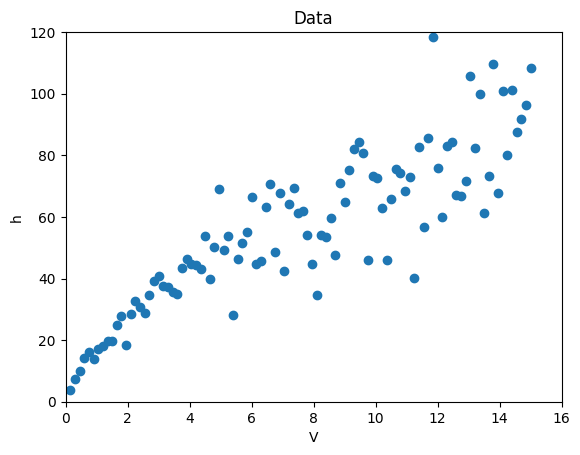

In [228]:
# We'll fit this data. The data is synthetic, but is based on the calculation of heat transfer coefficient from velocity
V = [ 0.15,  0.3 ,  0.45,  0.6 ,  0.75,  0.9 ,  1.05,  1.2 ,
        1.35,  1.5 ,  1.65,  1.8 ,  1.95,  2.1 ,  2.25,  2.4 ,  2.55,
        2.7 ,  2.85,  3.  ,  3.15,  3.3 ,  3.45,  3.6 ,  3.75,  3.9 ,
        4.05,  4.2 ,  4.35,  4.5 ,  4.65,  4.8 ,  4.95,  5.1 ,  5.25,
        5.4 ,  5.55,  5.7 ,  5.85,  6.  ,  6.15,  6.3 ,  6.45,  6.6 ,
        6.75,  6.9 ,  7.05,  7.2 ,  7.35,  7.5 ,  7.65,  7.8 ,  7.95,
        8.1 ,  8.25,  8.4 ,  8.55,  8.7 ,  8.85,  9.  ,  9.15,  9.3 ,
        9.45,  9.6 ,  9.75,  9.9 , 10.05, 10.2 , 10.35, 10.5 , 10.65,
       10.8 , 10.95, 11.1 , 11.25, 11.4 , 11.55, 11.7 , 11.85, 12.  ,
       12.15, 12.3 , 12.45, 12.6 , 12.75, 12.9 , 13.05, 13.2 , 13.35,
       13.5 , 13.65, 13.8 , 13.95, 14.1 , 14.25, 14.4 , 14.55, 14.7 ,
       14.85, 15.  ]
h = [   3.84093199,   7.47595498,   9.91584447,
        14.03542736,  16.23534068,  13.79378018,  17.13521136,
        18.04144439,  19.67060662,  19.78582372,  24.91883376,
        27.93849422,  18.5669067 ,  28.53855184,  32.56663638,
        30.86686781,  28.93616579,  34.77899276,  39.05285625,
        40.74881059,  37.62231127,  37.40291435,  35.53799145,
        35.05038485,  43.38419482,  46.21389388,  44.62615583,
        44.533906  ,  42.93340205,  53.82820976,  39.86884865,
        50.15224793,  68.97065936,  49.2462678 ,  53.91783748,
        28.24952189,  46.38458471,  51.66665474,  54.94683294,
        66.32087895,  44.84053638,  45.73587641,  63.08076713,
        70.63964589,  48.74442607,  67.90175201,  42.35245579,
        64.33408068,  69.2670794 ,  61.26215625,  61.9249102 ,
        54.12397539,  44.71788607,  34.78208514,  54.15431617,
        53.62388626,  59.66509929,  47.79667435,  71.16105218,
        64.72819232,  75.38922969,  81.94069361,  84.22436968,
        80.81152866,  45.93495294,  73.15539885,  72.66240629,
        62.97897346,  45.95356861,  65.86876962,  75.61620695,
        74.26085993,  68.30626027,  72.8969821 ,  40.03572342,
        82.82675315,  56.63991714,  85.53841792, 118.57016883,
        75.8656376 ,  60.00602931,  83.14626376,  84.19813951,
        67.275041  ,  66.94597975,  71.78879524, 105.72109012,
        82.51192043,  99.7670406 ,  61.34104925,  73.32594608,
       109.75237498,  67.83206339, 101.02154246,  80.07144211,
       101.07955673,  87.58180398,  91.82778877,  96.33543116,
       108.2998174 ]
# Plot it
plt.figure()
plt.scatter(V,h)
plt.xlim([0,16])
plt.ylim([0,120])
plt.xlabel('V')
plt.ylabel('h')
plt.title('Data')

In [229]:
# We want a powerlaw fit, h=CV^m. Taking the log of both sides yields a linear equation in the variables x=log(V) and y = log(h). See The Notes for more details.
x = np.log(V)
y = np.log(h)
# Define the martix, M, to be used in the least squares solution. See The Notes for an explanation of M.
I = np.ones_like(x) # a column of ones with the same size as x
A = np.column_stack((I,x)) # A matrix. The first column is I, the second column is x

In [ ]:
# Create a new Linear regression object to do the least squares solution
reg = linear.LinearRegression(fit_intercept=False) # Don't use fit_intercept=True unless the coefficent 'b' is known to be zero
# Fit the data using the regression
reg.fit(A,y)
# Extract the coefficients
b = reg.coef_[0]
C = np.exp(b)
m = reg.coef_[1]
print(f'The coefficients are solved: C={C} and m={m}')
# Look at the R^2 value 
R2 = reg.score(A,y)
print(f'The fit works pretty well. The R2 value is {R2}')

The coefficients are solved: C=16.943505718768627 and m=0.6118554528780193
The fit works pretty well. The R2 value is 0.8928024988047412


Text(0.5, 1.0, 'Data with Fit')

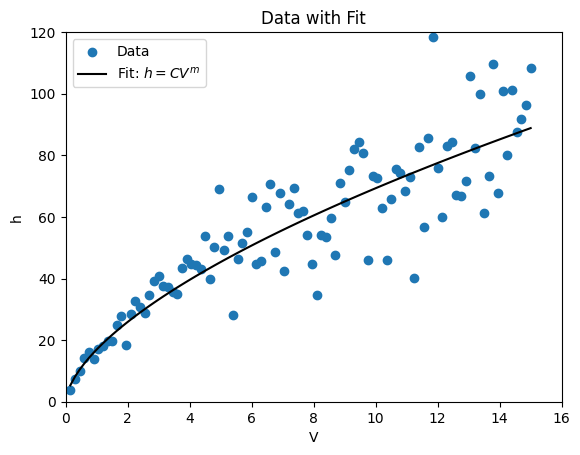

In [231]:
# Calculate the best fit curve and plot it with the data
h_fit = C*V**m
plt.figure()
plt.scatter(V,h,label='Data')
plt.plot(V,h_fit,'-k',label=r'Fit: $h=CV^m$')
plt.xlim([0,16])
plt.ylim([0,120])
plt.legend()
plt.xlabel('V')
plt.ylabel('h')
plt.title('Data with Fit')